# Eulers foward

h = 0.1 failed at step 4, t = 0.40000
h = 0.01 failed at step 7, t = 0.07000
h = 1e-05 failed: needs 3000000 steps
h = 1e-07 failed: needs 300000000 steps


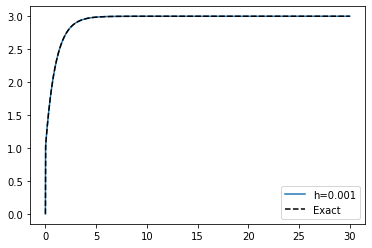

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def f(t,y):
    return (-1000*y + 3000 - 2000*np.exp(-t))

def exact(t):
    return (3 - .998*np.exp(-1000*t) - 2.002*np.exp(-t))

def Euler(y_not, step, start, stop, max_steps=1000000, max_y=1e6):
    # setup
    num_steps = int(round((stop - start) / step))
    
    # fail if too many steps
    if num_steps > max_steps:
        print(f"h = {step} failed: needs {num_steps} steps")
        return None, None

    x = np.linspace(start, stop, num_steps + 1)
    y = np.zeros(num_steps + 1)

    # initial condition
    x[0] = start
    y[0] = y_not

    # go through each step
    for i in range(num_steps):
        x[i+1] = x[i] + step
        y[i+1] = y[i] + step * f(x[i], y[i])

        # fail if solution blows up
        if not np.isfinite(y[i+1]) or abs(y[i+1]) > max_y:
            print(f"h = {step} failed at step {i+1}, t = {x[i+1]:.5f}")
            return None, None

    return x, y

h_vals = [.1, .01, .001, .00001, .0000001]

for j in range(len(h_vals)):
    h = h_vals[j]
    x, y = Euler(0, h, 0, 30)

    if x is not None and y is not None:
        plt.plot(x, y, label=f"h={h}")

x_exact = np.linspace(0, 30, 1000)
y_exact = exact(x_exact)
plt.plot(x_exact, y_exact, 'k--', label='Exact')

plt.legend()
plt.show()

AI citation:

- Chat- ChatGPT
- prompt - how can i write this so after a certain number of steps it just prints out that the step failes and moves on (attached current code with over flow error)
- why - i knew why the code wasnt running beacuse it was trying to gragh and approx a stiff equation but i wanted a way so something would run and it didnt just blurt out a overflow error and not work